<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/TTM/TTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

## TTM Squeeze Analysis

This code performs a comprehensive parameter sweep for a TTM Squeeze trading strategy across multiple symbols and configurations. It will identify optimal strategy configurations based on forward returns and win rates.

In [17]:
# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

### TTM Squeeze Configuration and Analysis

In [20]:
# --- 1. Configuration & Symbol Loading ---
# TTM Squeeze Configuration Parameters
BB_LENGTHS = [20, 25, 30]  # Bollinger Band lengths
KC_LENGTHS = [20, 25, 30]  # Keltner Channel lengths
KC_DEVS = [1.5, 2.0, 2.5]   # Keltner Channel deviation multiples
BB_DEVS = 2.0 # Standard Bollinger Band deviation

# Load Symbols from your OptionVolume
try:
    df_csv = pd.read_csv(OptionVolume)
    # Ensuring we handle different possible column names for Symbol
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from OptionVolume")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT"]

# --- 2. TTM Squeeze Function ---
def calculate_ttm_squeeze(df, bb_len, bb_dev, kc_len, kc_dev):
    # Bollinger Bands
    df['SMA'] = df['Close'].rolling(window=bb_len).mean()
    df['StdDev'] = df['Close'].rolling(window=bb_len).std()
    df['BB_Upper'] = df['SMA'] + (df['StdDev'] * bb_dev)
    df['BB_Lower'] = df['SMA'] - (df['StdDev'] * bb_dev)

    # Keltner Channels
    df['TR'] = np.maximum(df['High'] - df['Low'],
                          np.maximum(abs(df['High'] - df['Close'].shift()),
                                     abs(df['Low'] - df['Close'].shift())))
    df['ATR'] = df['TR'].rolling(window=kc_len).mean()
    df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['KC_Middle'] = df['Typical_Price'].rolling(window=kc_len).mean()
    df['KC_Upper'] = df['KC_Middle'] + (df['ATR'] * kc_dev)
    df['KC_Lower'] = df['KC_Middle'] - (df['ATR'] * kc_dev)

    # TTM Squeeze Condition: Squeeze is "on" when BB are inside KC
    df['in_squeeze'] = (df['BB_Lower'] > df['KC_Lower']) & \
                       (df['BB_Upper'] < df['KC_Upper'])
    return df

# --- 3. Data Fetching & Vectorized Math ---
print("Fetching data and calculating vectorized returns...")
data_cache = {}
for s in SYMBOLS:
    try:
        df = yf.download(s, period="5y", interval="1d", progress=False, auto_adjust=True)
        if df.empty: continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # VECTORIZED RETURN CALCULATION
        # Calculate percentage change and shift it backward to see future results
        df['Ret_3D'] = df['Close'].pct_change(3).shift(-3)
        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)
        df['Ret_10D'] = df['Close'].pct_change(10).shift(-10)

        data_cache[s] = df
    except:
        continue

# --- 4. Parameter Sweep ---
all_results = []

for bb_len in BB_LENGTHS:
    for kc_len in KC_LENGTHS:
        for kc_dev in KC_DEVS:
            param_trades = []

            for symbol, df_orig in data_cache.items():
                df = df_orig.copy()
                df = calculate_ttm_squeeze(df, bb_len=bb_len, bb_dev=BB_DEVS, kc_len=kc_len, kc_dev=kc_dev)

                # A common signal is when the squeeze *fires* (i.e., it was in a squeeze, and now it's not)
                # We are looking for the day the squeeze ends, after having been in a squeeze.
                condition = (df['in_squeeze'].shift(1) == True) & (df['in_squeeze'] == False)

                # Filter for the specific trigger day
                trades = df[condition].dropna(subset=['in_squeeze', 'Ret_10D']).copy()

                if not trades.empty:
                    trades['BB_Len'] = bb_len
                    trades['KC_Len'] = kc_len
                    trades['KC_Dev'] = kc_dev
                    trades['Symbol'] = symbol
                    param_trades.append(trades)

            if param_trades:
                combined = pd.concat(param_trades)
                all_results.append({
                    "BB_Len": bb_len,
                    "KC_Len": kc_len,
                    "KC_Dev": kc_dev,
                    "Avg_3D": combined['Ret_3D'].mean(),
                    "Avg_5D": combined['Ret_5D'].mean(),
                    "Avg_10D": combined['Ret_10D'].mean(),
                    "Win_Rate_3D": (combined['Ret_3D'] > 0).mean(),
                    "Win_Rate_5D": (combined['Ret_5D'] > 0).mean(),
                    "Win_Rate_10D": (combined['Ret_10D'] > 0).mean(),
                    "Trade_Count": len(combined)
                })

# --- 5. Summary Display ---
if all_results:
    summary_df = pd.DataFrame(all_results)
    # Sorting by 5D return as it's been our benchmark
    summary_df = summary_df.sort_values(by="Avg_5D", ascending=False)

    print("\n--- FULL LIST VECTORIZED TTM SQUEEZE OPTIMIZATION SUMMARY ---")
    display(summary_df)
    summary_df.to_csv("vectorized_ttm_squeeze_results.csv", index=False)
else:
    print("No trades found across the symbol list.")

Loaded 100 symbols from OptionVolume
Fetching data and calculating vectorized returns...

--- FULL LIST VECTORIZED TTM SQUEEZE OPTIMIZATION SUMMARY ---


,BB_Len,KC_Len,KC_Dev,Avg_3D,Avg_5D,Avg_10D,Win_Rate_3D,Win_Rate_5D,Win_Rate_10D,Trade_Count
17,25,30,2.5,0.004878,0.009669,0.020315,0.531632,0.551042,0.573688,2782
14,25,25,2.5,0.006658,0.009638,0.019893,0.546609,0.562094,0.578198,3229
26,30,30,2.5,0.004001,0.009350,0.018682,0.528309,0.553431,0.576303,2667
5,20,25,2.5,0.006092,0.008533,0.017777,0.534783,0.543768,0.565217,3450
11,25,20,2.5,0.004175,0.008402,0.016015,0.526610,0.539841,0.558659,3401
20,30,20,2.5,0.003960,0.008163,0.017360,0.521002,0.545279,0.552987,2595
7,20,30,2.0,0.003717,0.007956,0.019795,0.518077,0.544875,0.564866,2351
2,20,20,2.5,0.005105,0.007740,0.018069,0.531391,0.541722,0.550993,3775
23,30,25,2.5,0.004607,0.007650,0.018570,0.532181,0.548363,0.571166,2719
8,20,30,2.5,0.005857,0.007632,0.017605,0.538336,0.541272,0.568026,3065


##Win Rate Heat Maps

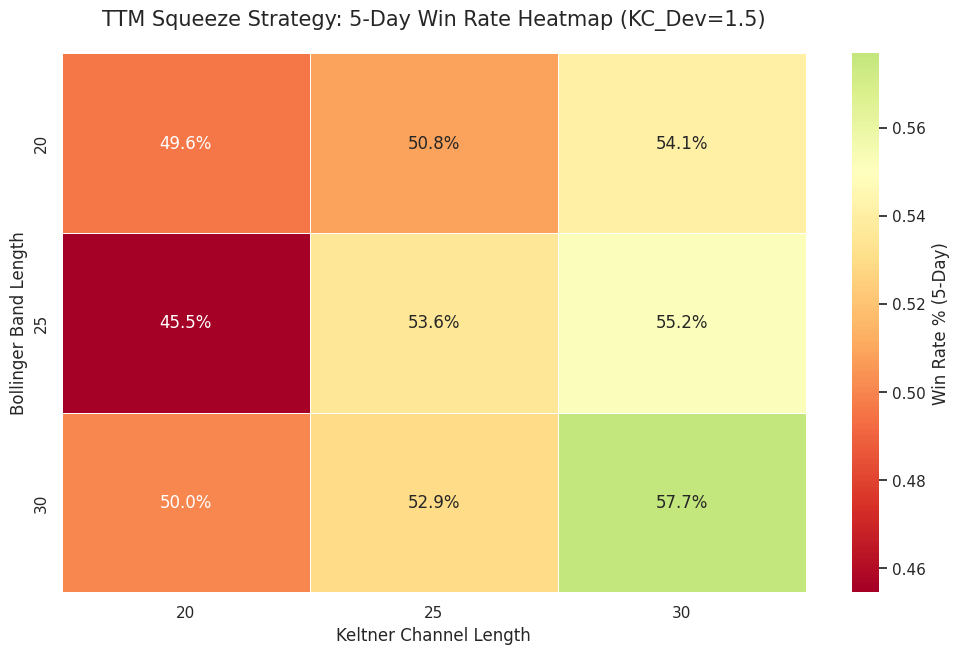

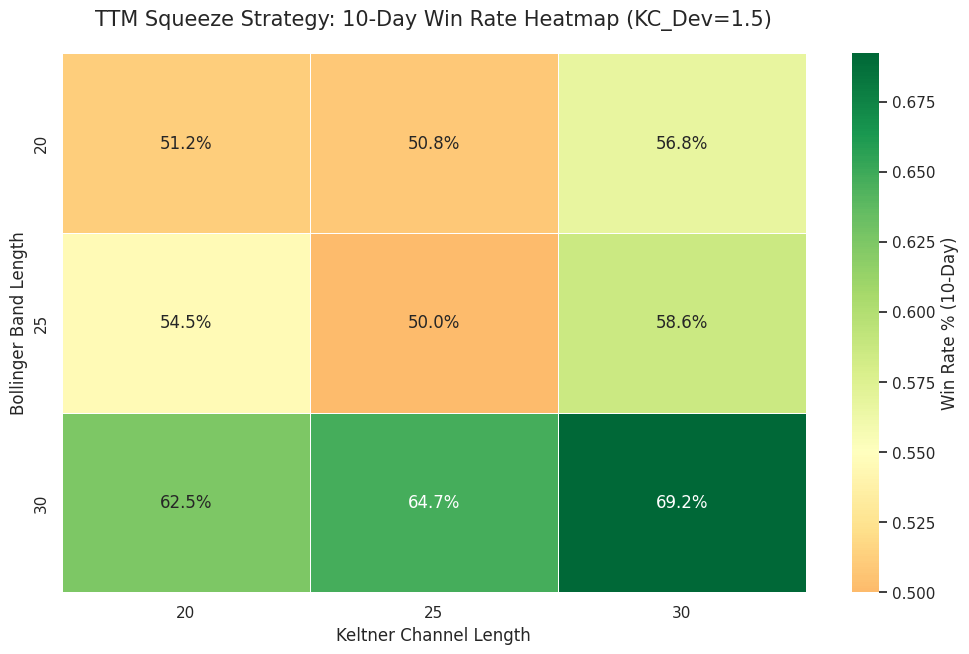

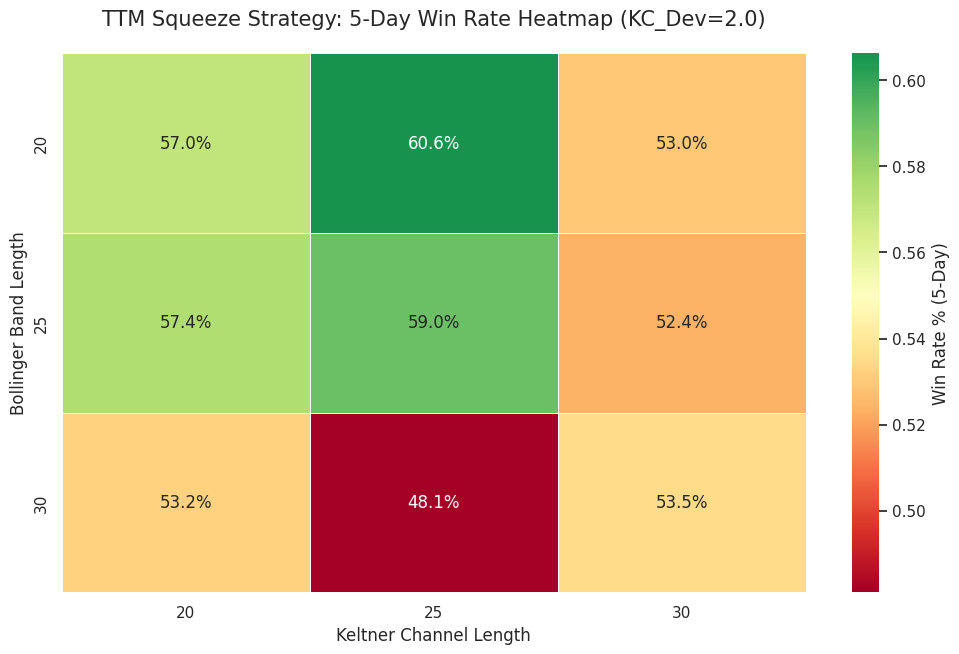

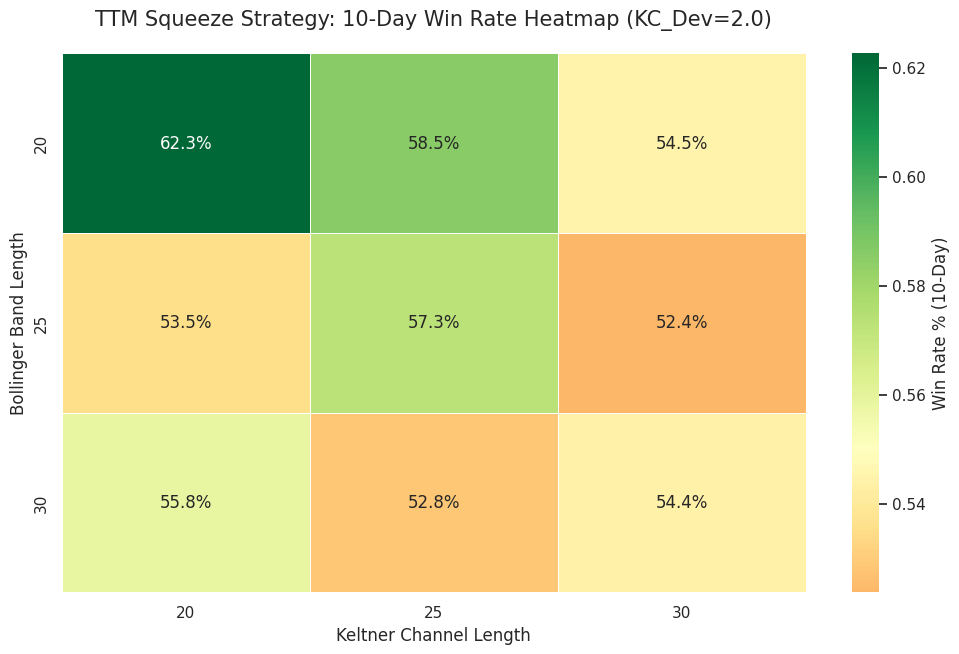

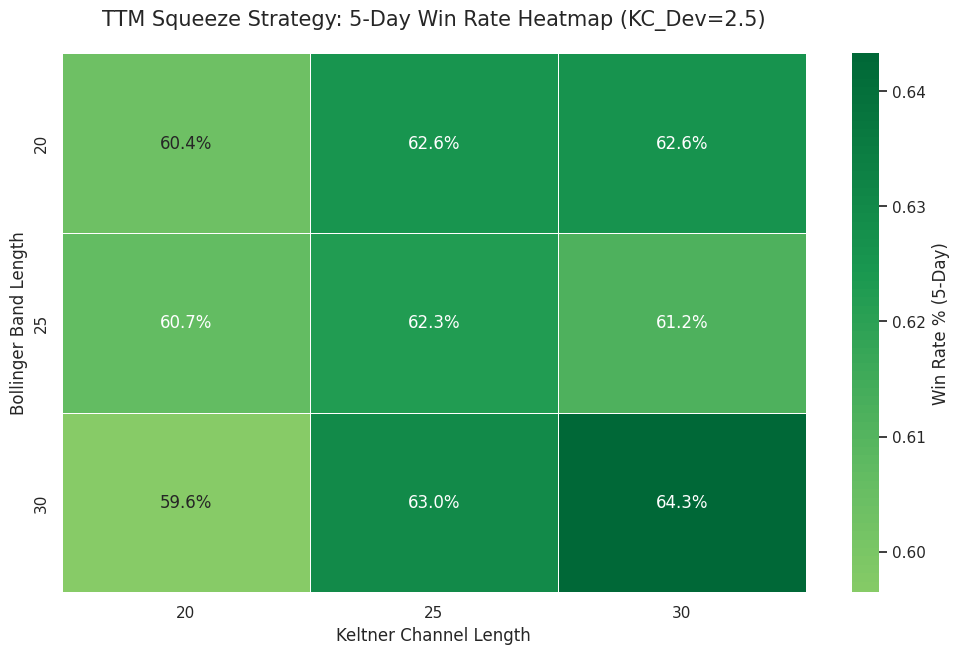

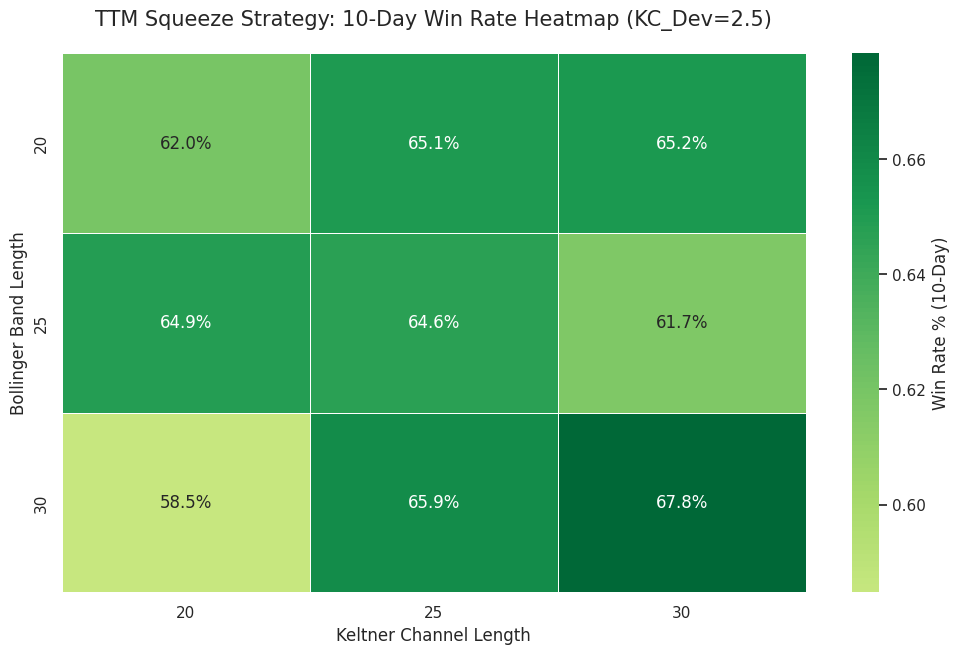

In [11]:
unique_kc_devs = summary_df['KC_Dev'].unique()

for kc_dev_val in sorted(unique_kc_devs):
    df_filtered = summary_df[summary_df['KC_Dev'] == kc_dev_val].copy()

    # 1. Pivot the data for 5-Day Win Rate
    heatmap_data_5d = df_filtered.pivot(index="BB_Len", columns="KC_Len", values="Win_Rate_5D")

    # 2. Set up the figure for 5-Day Win Rate Heatmap
    plt.figure(figsize=(12, 7))

    # 3. Create the heatmap for 5-Day Win Rate
    sns.heatmap(
        heatmap_data_5d,
        annot=True,
        fmt=".1%",
        cmap="RdYlGn",
        vmin=df_filtered["Win_Rate_5D"].min(),
        vmax=df_filtered["Win_Rate_5D"].max(),
        center=0.55,
        linewidths=.5,
        cbar_kws={'label': 'Win Rate % (5-Day)'}
    )

    # 4. Labels for 5-Day Win Rate Heatmap
    plt.title(f"TTM Squeeze Strategy: 5-Day Win Rate Heatmap (KC_Dev={kc_dev_val})", fontsize=15, pad=20)
    plt.xlabel("Keltner Channel Length", fontsize=12)
    plt.ylabel("Bollinger Band Length", fontsize=12)
    plt.show()

    # --- Separator for 10-Day Win Rate Heatmap ---

    # 1. Pivot the data for 10-Day Win Rate
    heatmap_data_10d = df_filtered.pivot(index="BB_Len", columns="KC_Len", values="Win_Rate_10D")

    # 2. Set up the figure for 10-Day Win Rate Heatmap
    plt.figure(figsize=(12, 7))

    # 3. Create the heatmap for 10-Day Win Rate
    sns.heatmap(
        heatmap_data_10d,
        annot=True,
        fmt=".1%",
        cmap="RdYlGn",
        vmin=df_filtered["Win_Rate_10D"].min(),
        vmax=df_filtered["Win_Rate_10D"].max(),
        center=0.55,
        linewidths=.5,
        cbar_kws={'label': 'Win Rate % (10-Day)'}
    )

    # 4. Labels for 10-Day Win Rate Heatmap
    plt.title(f"TTM Squeeze Strategy: 10-Day Win Rate Heatmap (KC_Dev={kc_dev_val})", fontsize=15, pad=20)
    plt.xlabel("Keltner Channel Length", fontsize=12)
    plt.ylabel("Bollinger Band Length", fontsize=12)
    plt.show()

## Average Return Heatmaps

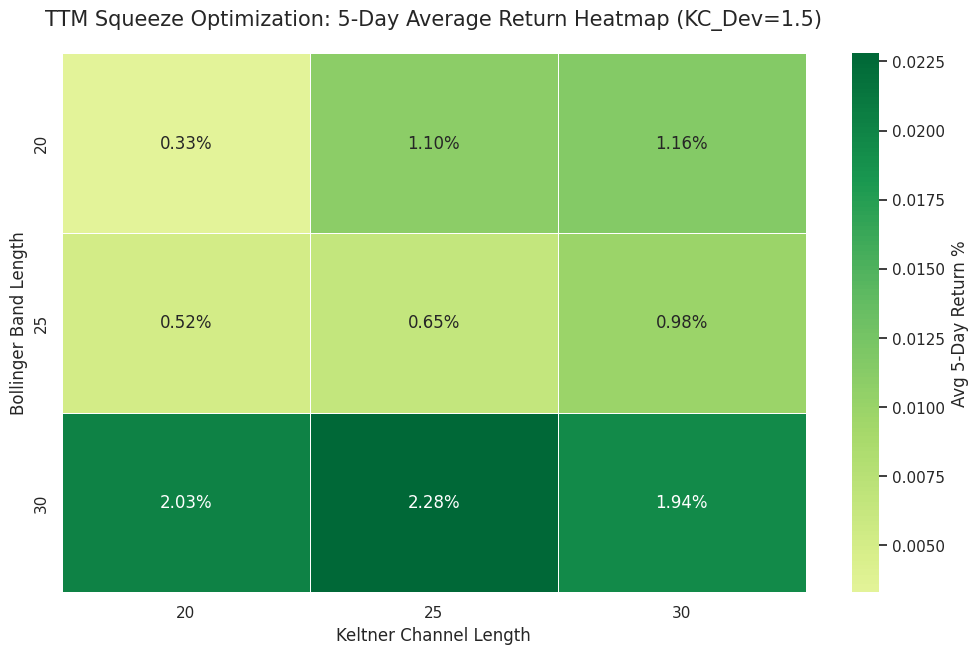

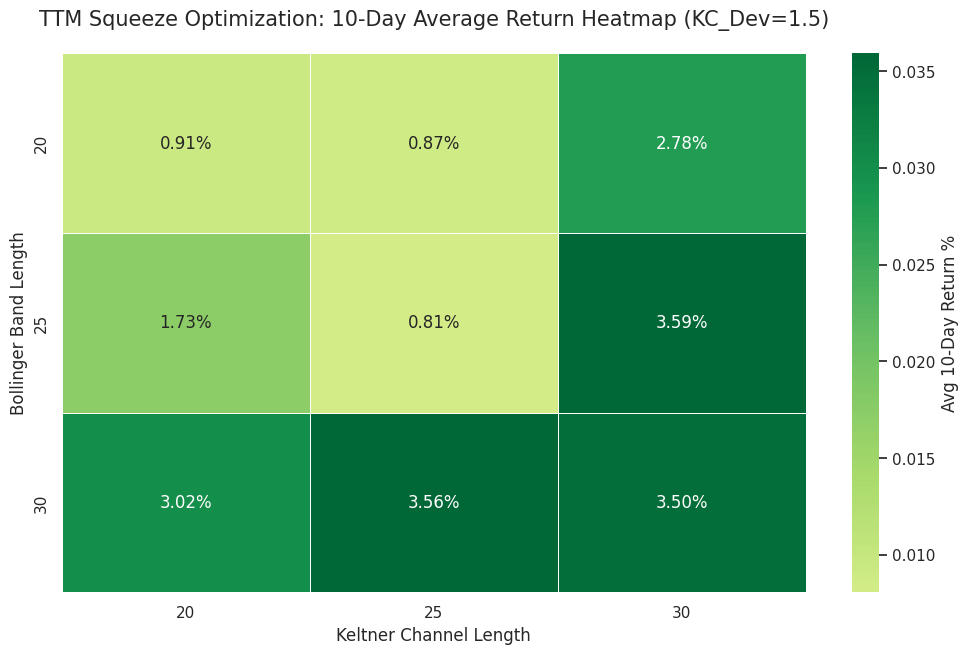

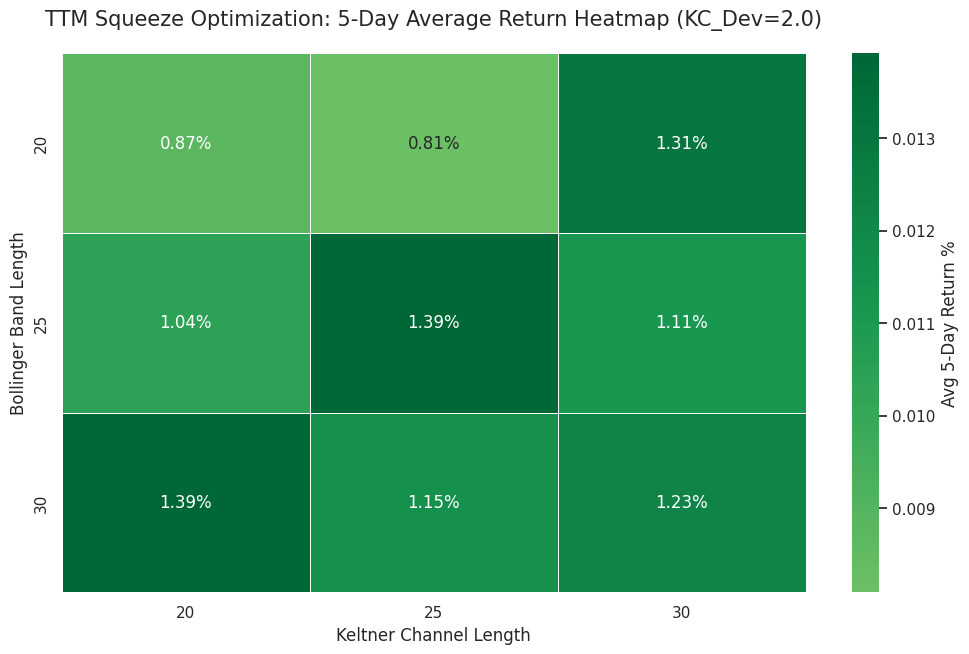

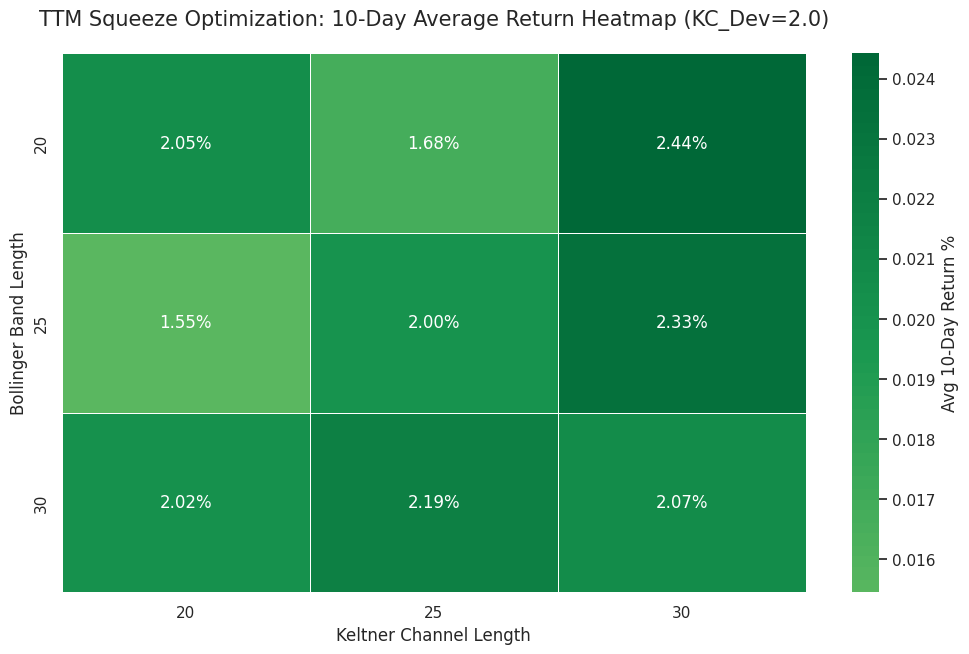

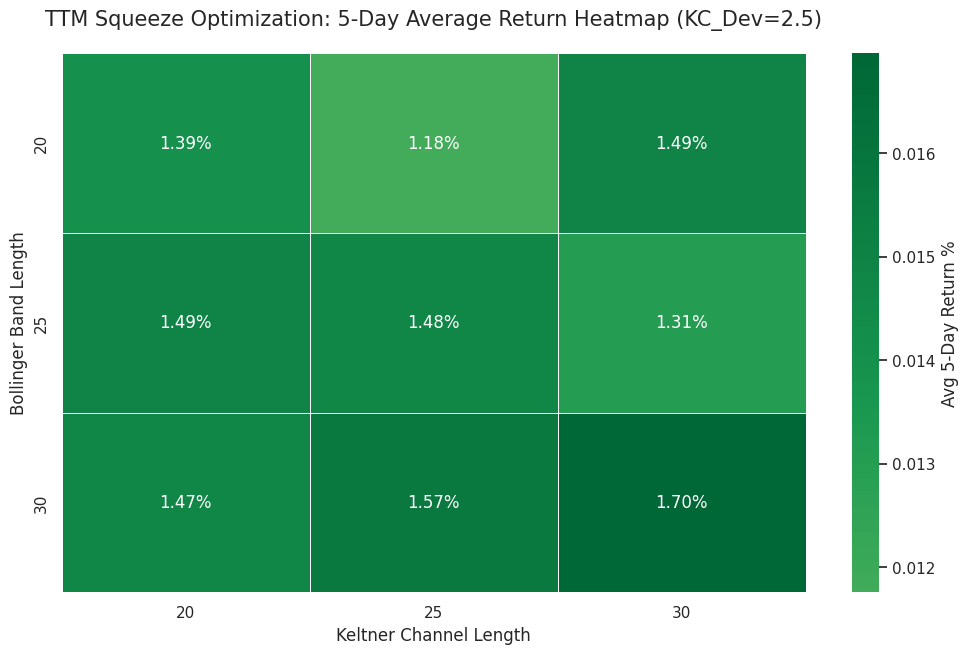

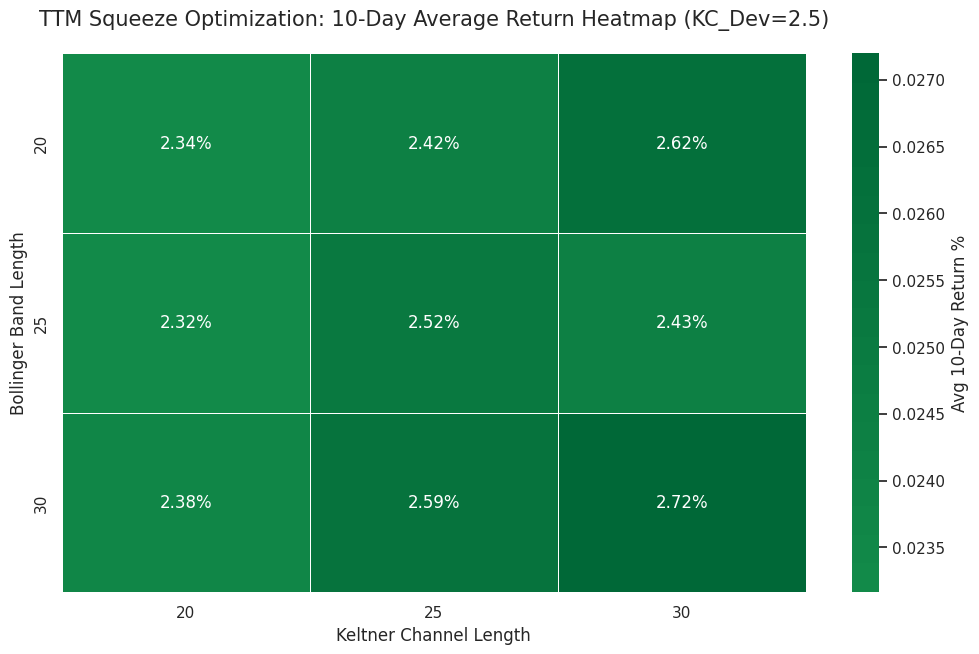

In [12]:
unique_kc_devs = summary_df['KC_Dev'].unique()

for kc_dev_val in sorted(unique_kc_devs):
    df_filtered = summary_df[summary_df['KC_Dev'] == kc_dev_val].copy()

    # 1. Pivot the data for Average 5-Day Return
    heatmap_data_5d_avg = df_filtered.pivot(index="BB_Len", columns="KC_Len", values="Avg_5D")

    # 2. Set up the figure for Average 5-Day Return Heatmap
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="white")

    # 3. Create the heatmap with optimized gradient parameters
    sns.heatmap(
        heatmap_data_5d_avg,
        annot=True,
        fmt=".2%",
        cmap="RdYlGn",
        vmin=df_filtered["Avg_5D"].min(),
        vmax=df_filtered["Avg_5D"].max(),
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Avg 5-Day Return %'}
    )

    # 4. Labels and Title
    plt.title(f"TTM Squeeze Optimization: 5-Day Average Return Heatmap (KC_Dev={kc_dev_val})", fontsize=15, pad=20)
    plt.xlabel("Keltner Channel Length", fontsize=12)
    plt.ylabel("Bollinger Band Length", fontsize=12)
    plt.show()

    # --- Separator for Average 10-Day Return Heatmap ---

    # 1. Pivot the data for Average 10-Day Return
    heatmap_data_10d_avg = df_filtered.pivot(index="BB_Len", columns="KC_Len", values="Avg_10D")

    # 2. Set up the figure for Average 10-Day Return Heatmap
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="white")

    # 3. Create the heatmap with optimized gradient parameters
    sns.heatmap(
        heatmap_data_10d_avg,
        annot=True,
        fmt=".2%",
        cmap="RdYlGn",
        vmin=df_filtered["Avg_10D"].min(),
        vmax=df_filtered["Avg_10D"].max(),
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Avg 10-Day Return %'}
    )

    # 4. Labels and Title
    plt.title(f"TTM Squeeze Optimization: 10-Day Average Return Heatmap (KC_Dev={kc_dev_val})", fontsize=15, pad=20)
    plt.xlabel("Keltner Channel Length", fontsize=12)
    plt.ylabel("Bollinger Band Length", fontsize=12)
    plt.show()

## 2022 TTM Squeeze Backtest

In [21]:
# --- 1. Configuration & Symbol Loading ---
# TTM Squeeze Configuration Parameters
BB_LENGTHS = [20, 25, 30]  # Bollinger Band lengths
KC_LENGTHS = [20, 25, 30]  # Keltner Channel lengths
KC_DEVS = [1.5, 2.0, 2.5]   # Keltner Channel deviation multiples
BB_DEVS = 2.0 # Standard Bollinger Band deviation

# Data window to capture all of 2022 with buffers for indicators and returns
START_DATE = "2021-11-01"
END_DATE = "2023-01-20"

try:
    df_csv = pd.read_csv(OptionVolume)
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from OptionVolume")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT", "AMD", "META"]

# --- 2. TTM Squeeze Function ---
def calculate_ttm_squeeze(df, bb_len, bb_dev, kc_len, kc_dev):
    # Bollinger Bands
    df['SMA'] = df['Close'].rolling(window=bb_len).mean()
    df['StdDev'] = df['Close'].rolling(window=bb_len).std()
    df['BB_Upper'] = df['SMA'] + (df['StdDev'] * bb_dev)
    df['BB_Lower'] = df['SMA'] - (df['StdDev'] * bb_dev)

    # Keltner Channels
    df['TR'] = np.maximum(df['High'] - df['Low'],
                          np.maximum(abs(df['High'] - df['Close'].shift()),
                                     abs(df['Low'] - df['Close'].shift())))
    df['ATR'] = df['TR'].rolling(window=kc_len).mean()
    df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['KC_Middle'] = df['Typical_Price'].rolling(window=kc_len).mean()
    df['KC_Upper'] = df['KC_Middle'] + (df['ATR'] * kc_dev)
    df['KC_Lower'] = df['KC_Middle'] - (df['ATR'] * kc_dev)

    # TTM Squeeze Condition: Squeeze is "on" when BB are inside KC
    df['in_squeeze'] = (df['BB_Lower'] > df['KC_Lower']) & \
                       (df['BB_Upper'] < df['KC_Upper'])
    return df

# --- 3. Data Fetching & Vectorized Math ---
print(f"Fetching data from {START_DATE} to {END_DATE}...")
data_cache = {}
for s in SYMBOLS:
    try:
        df = yf.download(s, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)
        if df.empty: continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Vectorized Future Returns (Shifted backwards)
        df['Ret_3D'] = df['Close'].pct_change(3).shift(-3)
        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)
        df['Ret_10D'] = df['Close'].pct_change(10).shift(-10)

        data_cache[s] = df
    except:
        continue

# --- 4. Parameter Sweep for 2022 ---
all_results = []

print("Running 2022 Analysis...")
for bb_len in BB_LENGTHS:
    for kc_len in KC_LENGTHS:
        for kc_dev in KC_DEVS:
            param_trades = []

            for symbol, df_orig in data_cache.items():
                df = df_orig.copy()
                df = calculate_ttm_squeeze(df, bb_len=bb_len, bb_dev=BB_DEVS, kc_len=kc_len, kc_dev=kc_dev)

                # --- CRITICAL FILTER: Only include signals that triggered in 2022 ---
                mask_2022 = (df.index >= "2022-01-01") & (df.index <= "2022-12-31")
                # Squeeze fires when it was in squeeze, and now it's not.
                condition = (df['in_squeeze'].shift(1) == True) & (df['in_squeeze'] == False)
                trades = df[mask_2022 & condition].dropna(subset=['in_squeeze', 'Ret_10D']).copy()

                if not trades.empty:
                    trades['BB_Len'] = bb_len
                    trades['KC_Len'] = kc_len
                    trades['KC_Dev'] = kc_dev
                    trades['Symbol'] = symbol
                    param_trades.append(trades)

            if param_trades:
                combined = pd.concat(param_trades)
                all_results.append({
                    "BB_Len": bb_len,
                    "KC_Len": kc_len,
                    "KC_Dev": kc_dev,
                    "Avg_3D": combined['Ret_3D'].mean(),
                    "Avg_5D": combined['Ret_5D'].mean(),
                    "Avg_10D": combined['Ret_10D'].mean(),
                    "Win_Rate_3D": (combined['Ret_3D'] > 0).mean(),
                    "Win_Rate_5D": (combined['Ret_5D'] > 0).mean(),
                    "Win_Rate_10D": (combined['Ret_10D'] > 0).mean(),
                    "Trade_Count": len(combined)
                })

# --- 5. Summary Table ---
if all_results:
    summary_df_2022 = pd.DataFrame(all_results)
    summary_df_2022 = summary_df_2022.sort_values(by="Avg_5D", ascending=False)

    print("\n--- 2022 TTM SQUEEZE BACKTEST SUMMARY ---")
    display(summary_df_2022)
    summary_df_2022.to_csv("ttm_squeeze_results_2022.csv", index=False)
else:
    print("No trades triggered in 2022 with current parameters.")

Loaded 100 symbols from OptionVolume
Fetching data from 2021-11-01 to 2023-01-20...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['IBIT']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CRWV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NBIS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
E

Running 2022 Analysis...

--- 2022 TTM SQUEEZE BACKTEST SUMMARY ---


,BB_Len,KC_Len,KC_Dev,Avg_3D,Avg_5D,Avg_10D,Win_Rate_3D,Win_Rate_5D,Win_Rate_10D,Trade_Count
22,30,25,2.0,0.000898,0.006166,0.008831,0.470270,0.491892,0.500000,370
15,25,30,1.5,0.004796,0.004278,0.016925,0.517241,0.517241,0.568966,116
26,30,30,2.5,-0.002187,0.004190,0.001843,0.470280,0.503497,0.508741,572
19,30,20,2.0,0.000487,0.003057,0.013258,0.480645,0.477419,0.522581,310
18,30,20,1.5,-0.001590,0.001398,0.015989,0.540541,0.527027,0.581081,74
23,30,25,2.5,-0.001356,0.000740,-0.000165,0.465398,0.503460,0.498270,578
17,25,30,2.5,-0.001973,0.000448,-0.001718,0.454545,0.479798,0.474747,594
24,30,30,1.5,0.000114,0.000329,0.011648,0.504762,0.476190,0.514286,105
21,30,25,1.5,-0.003188,0.000027,0.005554,0.530120,0.542169,0.493976,83
11,25,20,2.5,-0.001110,-0.000408,-0.002888,0.482900,0.471956,0.484268,731


## Visualize 2022 TTM Squeeze Backtest Data

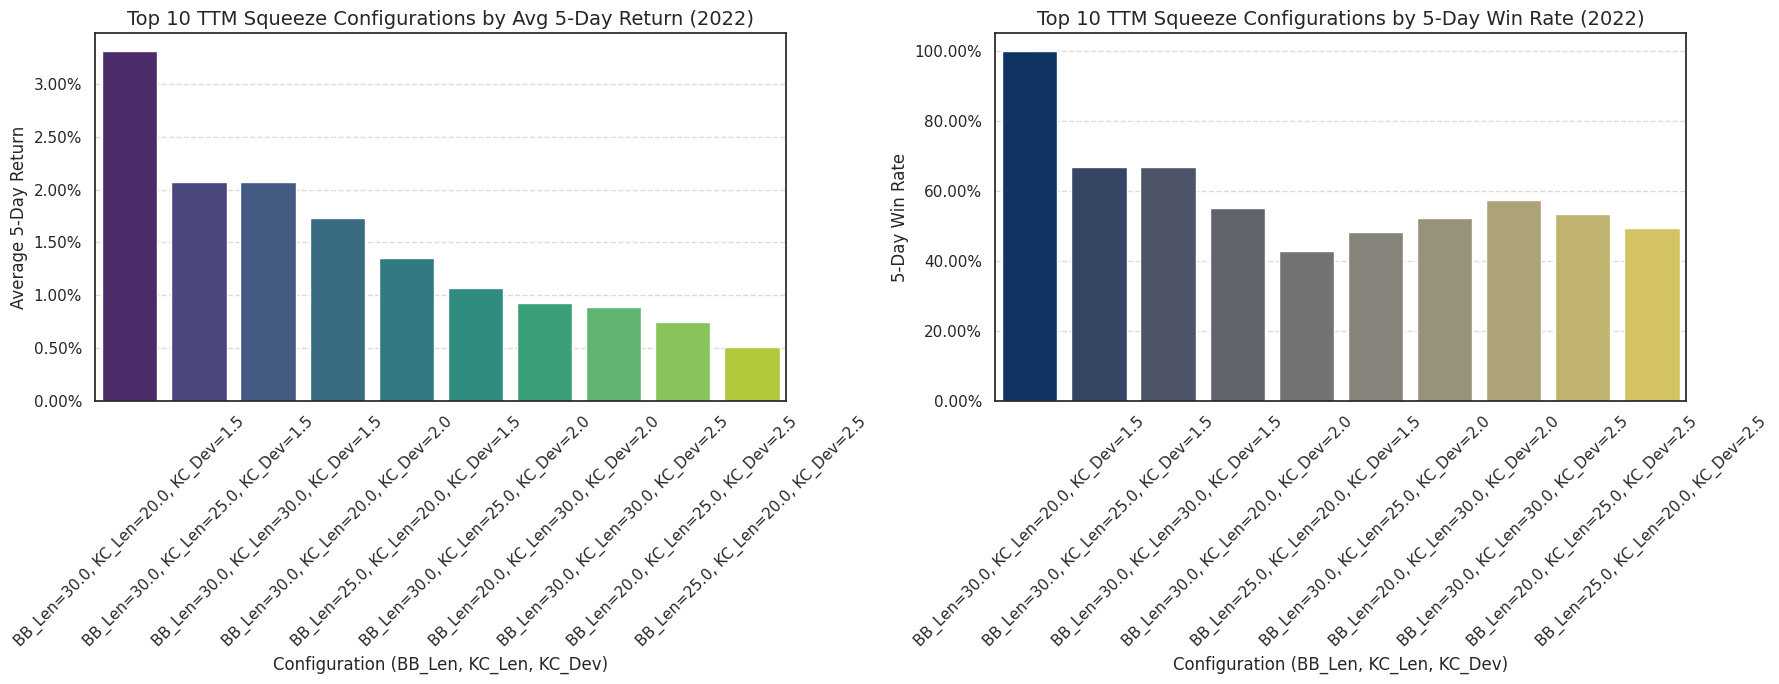


--- Top 10 TTM Squeeze Configurations (2022 Backtest) ---


,BB_Len,KC_Len,KC_Dev,Avg_5D,Win_Rate_5D,Trade_Count
18,30,20,1.5,0.033151,1.000000,1
21,30,25,1.5,0.020723,0.666667,3
24,30,30,1.5,0.020723,0.666667,3
19,30,20,2.0,0.017348,0.550000,20
9,25,20,1.5,0.013505,0.428571,7
22,30,25,2.0,0.010667,0.481481,27
7,20,30,2.0,0.009258,0.522727,44
26,30,30,2.5,0.008879,0.574074,54
5,20,25,2.5,0.007479,0.533333,60
11,25,20,2.5,0.005085,0.493151,73


In [16]:
# Assuming summary_df_2022 contains the results from the 2022 TTM Squeeze Backtest

if 'summary_df_2022' in locals() and not summary_df_2022.empty:

    # Sort for better visualization if not already sorted
    df_plot = summary_df_2022.sort_values(by='Avg_5D', ascending=False).head(10)

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot 1: Average 5-Day Return
    sns.barplot(
        x=['BB_Len=' + str(r['BB_Len']) + ', KC_Len=' + str(r['KC_Len']) + ', KC_Dev=' + str(r['KC_Dev']) for idx, r in df_plot.iterrows()],
        y='Avg_5D',
        data=df_plot,
        ax=axes[0],
        palette='viridis',
        hue=['BB_Len=' + str(r['BB_Len']) + ', KC_Len=' + str(r['KC_Len']) + ', KC_Dev=' + str(r['KC_Dev']) for idx, r in df_plot.iterrows()],
        legend=False
    )
    axes[0].set_title('Top 10 TTM Squeeze Configurations by Avg 5-Day Return (2022)', fontsize=14)
    axes[0].set_ylabel('Average 5-Day Return', fontsize=12)
    axes[0].set_xlabel('Configuration (BB_Len, KC_Len, KC_Dev)', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot 2: 5-Day Win Rate
    sns.barplot(
        x=['BB_Len=' + str(r['BB_Len']) + ', KC_Len=' + str(r['KC_Len']) + ', KC_Dev=' + str(r['KC_Dev']) for idx, r in df_plot.iterrows()],
        y='Win_Rate_5D',
        data=df_plot,
        ax=axes[1],
        palette='cividis',
        hue=['BB_Len=' + str(r['BB_Len']) + ', KC_Len=' + str(r['KC_Len']) + ', KC_Dev=' + str(r['KC_Dev']) for idx, r in df_plot.iterrows()],
        legend=False
    )
    axes[1].set_title('Top 10 TTM Squeeze Configurations by 5-Day Win Rate (2022)', fontsize=14)
    axes[1].set_ylabel('5-Day Win Rate', fontsize=12)
    axes[1].set_xlabel('Configuration (BB_Len, KC_Len, KC_Dev)', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Print the top configurations in a table format
    print("\n--- Top 10 TTM Squeeze Configurations (2022 Backtest) ---")
    display(df_plot[['BB_Len', 'KC_Len', 'KC_Dev', 'Avg_5D', 'Win_Rate_5D', 'Trade_Count']])

else:
    print("No 2022 backtest results found to visualize. Please run the previous cell.")